# Can a simple rating beat the bookmakers? Elo for Europe's top five leagues

**Every match from 15 seasons of the Premier League, Bundesliga, La Liga, Serie A and Ligue 1** (about 26,000 matches, 2010/11 to 2024/25). The notebook builds an **Elo rating** for every club from the results alone, turns rating differences into win, draw and loss probabilities with a logistic regression, adds recent form as a second feature, and then compares everything honestly: models are fitted on 2012-2019 and judged on the **2019/20 to 2024/25 seasons they never saw**, against the probabilities implied by Bet365's odds.

**Data:** one CSV per league and season from [football-data.co.uk](https://www.football-data.co.uk/data.php) (free for personal use). The notebook downloads them (about 9 MB) into `FOOTBALL_DIR` the first time it runs.

In [1]:
import csv
import os
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path(os.environ.get("FOOTBALL_DIR", "football_data"))
DATA_DIR.mkdir(exist_ok=True)
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})

LEAGUES = {"E0": "Premier League", "D1": "Bundesliga", "SP1": "La Liga", "I1": "Serie A", "F1": "Ligue 1"}
SEASONS = [f"{y:02d}{y + 1:02d}" for y in range(10, 25)]          # 1011 ... 2425

## 1. Load the matches

Some of the source files have rows with more fields than the header, so they are read with the `csv` module and the extra fields are cut off. Only what the model needs is kept: date, teams, full-time score and Bet365's three match odds.

In [2]:
def read_season(league, season):
    path = DATA_DIR / f"{league}_{season}.csv"
    if not path.exists():
        urllib.request.urlretrieve(f"https://www.football-data.co.uk/mmz4281/{season}/{league}.csv", path)
    with open(path, encoding="utf-8-sig", errors="replace", newline="") as f:
        rows = list(csv.reader(f))
    header = [h.strip() for h in rows[0]]
    body = [(r + [""] * len(header))[:len(header)] for r in rows[1:] if any(c.strip() for c in r)]
    df = pd.DataFrame(body, columns=header)
    df = df[["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "B365H", "B365D", "B365A"]].copy()
    df.insert(0, "league", LEAGUES[league])
    df.insert(1, "season", f"20{season[:2]}/{season[2:]}")
    return df


raw = pd.concat([read_season(lg, s) for lg in LEAGUES for s in SEASONS], ignore_index=True)
matches = raw.rename(columns={"Date": "date", "HomeTeam": "home", "AwayTeam": "away", "FTHG": "hg", "FTAG": "ag",
                              "FTR": "result", "B365H": "odds_h", "B365D": "odds_d", "B365A": "odds_a"})
matches["date"] = pd.to_datetime(matches["date"], dayfirst=True, format="mixed")
for col in ["hg", "ag", "odds_h", "odds_d", "odds_a"]:
    matches[col] = pd.to_numeric(matches[col], errors="coerce")
matches = matches.dropna(subset=["hg", "ag", "result"]).sort_values(["date", "league"]).reset_index(drop=True)

print(f"{len(matches):,} matches, {matches.date.min():%Y-%m-%d} to {matches.date.max():%Y-%m-%d}; "
      f"{matches.odds_h.isna().sum()} without odds")
matches.groupby("league").agg(matches=("result", "size"), home_win=("result", lambda s: (s == "H").mean()),
                              draw=("result", lambda s: (s == "D").mean()), goals=("hg", "mean")).round(3)

27,141 matches, 2010-08-07 to 2025-05-25; 8 without odds


,matches,home_win,draw,goals
league,,,,
Bundesliga,4590,0.447,0.244,1.683
La Liga,5700,0.465,0.251,1.538
Ligue 1,5451,0.441,0.266,1.472
Premier League,5700,0.449,0.240,1.556
Serie A,5700,0.436,0.260,1.498


## 2. Build the Elo ratings

Every club starts at 1500 (promoted clubs at 1450). After each match the winner takes points from the loser in proportion to how *surprising* the result was: beating a much stronger club earns a lot, beating a weak one very little. Home teams get a built-in rating bonus, bigger wins count more (the multiplier used by World Football Elo), and between seasons every rating is pulled 15% back towards 1500 because squads change. Two knobs are tuned on validation seasons instead of guessed: `k` (how fast ratings move) and the home bonus used inside the update.

In [3]:
def run_elo(df, k=20.0, home_adv=65.0, new_team=1450.0, carry=0.85):
    """One pass over the matches in date order. Returns pre-match ratings and a rating history."""
    ratings, league_season = {}, {}
    pre_h = np.empty(len(df))
    pre_a = np.empty(len(df))
    history = []
    for i, row in enumerate(df.itertuples(index=False)):
        if league_season.get(row.league) != row.season:            # a new season starts in this league
            for key in [k_ for k_ in ratings if k_[0] == row.league]:
                ratings[key] = 1500 + carry * (ratings[key] - 1500)
            league_season[row.league] = row.season
        kh, ka = (row.league, row.home), (row.league, row.away)
        rh, ra = ratings.setdefault(kh, new_team), ratings.setdefault(ka, new_team)
        pre_h[i], pre_a[i] = rh, ra
        expected = 1 / (1 + 10 ** (-(rh + home_adv - ra) / 400))
        actual = {"H": 1.0, "D": 0.5, "A": 0.0}[row.result]
        margin = abs(row.hg - row.ag)
        mult = 1.0 if margin <= 1 else 1.5 if margin == 2 else (11 + margin) / 8
        delta = k * mult * (actual - expected)
        ratings[kh], ratings[ka] = rh + delta, ra - delta
        history.append((row.date, row.league, row.home, ratings[kh]))
        history.append((row.date, row.league, row.away, ratings[ka]))
    return pre_h, pre_a, pd.DataFrame(history, columns=["date", "league", "team", "rating"])


CLASSES = ["H", "D", "A"]
y_all = matches.result.map({c: i for i, c in enumerate(CLASSES)}).to_numpy()

# split by season: ratings warm up on 2010-12, models are fitted on 2012/13-2016/17, tuned on 2017/18-2018/19, tested on 2019/20 onwards
first_year = matches.season.str[:4].astype(int)
train = ((first_year >= 2012) & (first_year <= 2016)).to_numpy()
valid = ((first_year >= 2017) & (first_year <= 2018)).to_numpy()
test = (first_year >= 2019).to_numpy()
print(f"train {train.sum():,} | validation {valid.sum():,} | test {test.sum():,} matches")

train 9,130 | validation 3,652 | test 10,707 matches


### Choosing `k` and the home bonus

A small grid search: for each setting the ratings are rebuilt, a one-feature logistic regression on the rating gap is fitted on the training seasons, and the **log-loss** (lower is better, it punishes confident wrong predictions) is measured on the validation seasons. The grid turns out to be almost flat: the regression has its own intercept, so a constant home bonus is absorbed and barely changes the predictions, and anything between `k` = 10 and 40 gives nearly the same loss. A simple Elo is not sensitive to its settings.

In [4]:
from sklearn.metrics import log_loss

rows = []
for k in [10, 15, 20, 30, 40]:
    for home_adv in [40, 60, 80]:
        ph, pa, _ = run_elo(matches, k=k, home_adv=home_adv)
        x = (ph + home_adv - pa).reshape(-1, 1)
        model = LogisticRegression().fit(x[train], y_all[train])
        rows.append((k, home_adv, log_loss(y_all[valid], model.predict_proba(x[valid]), labels=[0, 1, 2])))
grid = pd.DataFrame(rows, columns=["k", "home_adv", "validation_log_loss"]).sort_values("validation_log_loss")
best = grid.iloc[0]
K, HOME = float(best.k), float(best.home_adv)
print(f"best: k={K:g}, home bonus={HOME:g}")
grid.head(6).round(4)

best: k=15, home bonus=40


,k,home_adv,validation_log_loss
3,15,40,0.9756
4,15,60,0.9756
0,10,40,0.9756
5,15,80,0.9756
1,10,60,0.9757
2,10,80,0.9757


In [5]:
pre_h, pre_a, history = run_elo(matches, k=K, home_adv=HOME)
matches["elo_h"], matches["elo_a"] = pre_h, pre_a
matches["elo_diff"] = pre_h + HOME - pre_a

latest = (history.sort_values("date").groupby(["league", "team"]).tail(1)
          .sort_values("date").groupby("league").tail(30))
last_date = matches.date.max()
current = (history[history.date >= last_date - pd.Timedelta(days=14)].sort_values("date")
           .groupby(["league", "team"], as_index=False).last())
top = current.sort_values("rating", ascending=False).groupby("league").head(3).sort_values(["league", "rating"], ascending=[True, False])
top.assign(rating=top.rating.round(0))[["league", "team", "rating"]].reset_index(drop=True)

,league,team,rating
0,Bundesliga,Bayern Munich,1749.0
1,Bundesliga,Leverkusen,1702.0
2,Bundesliga,Dortmund,1631.0
3,La Liga,Barcelona,1752.0
4,La Liga,Real Madrid,1738.0
5,La Liga,Ath Madrid,1664.0
6,Ligue 1,Paris SG,1779.0
7,Ligue 1,Monaco,1634.0
8,Ligue 1,Lille,1621.0
9,Premier League,Liverpool,1724.0


## 3. How have the big clubs' ratings moved?

One line per club, the rating after every match. Ratings are only comparable *inside* a league (each league is its own pool), so the chart shows each club against its own league's average of 1500.

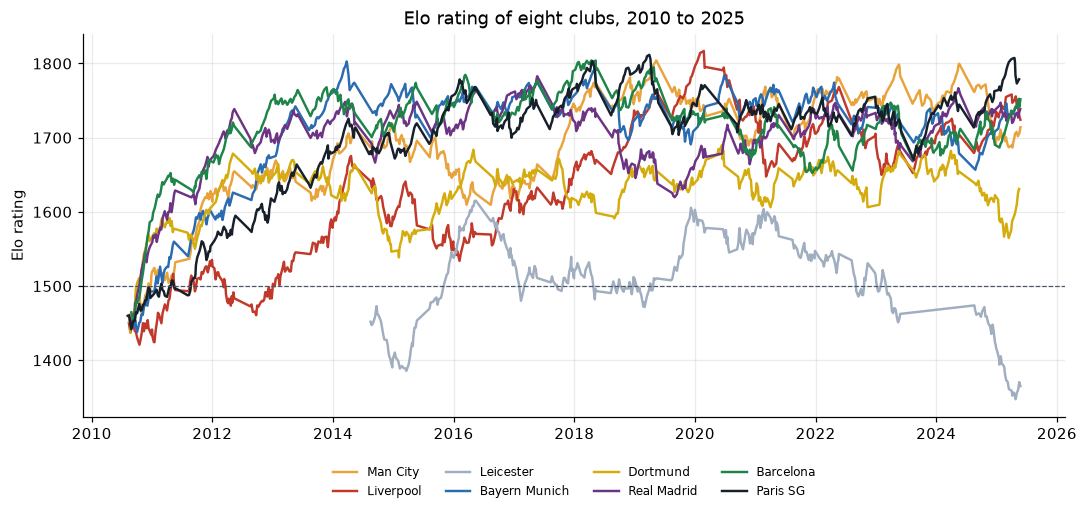

In [6]:
clubs = {"Man City": AMBER, "Liverpool": "#c0392b", "Leicester": GREY, "Bayern Munich": BLUE, "Dortmund": "#d4ac0d",
         "Real Madrid": "#6c3483", "Barcelona": "#1e8449", "Paris SG": "#17202a"}
fig, ax = plt.subplots(figsize=(10, 4.8))
for club, color in clubs.items():
    h = history[history.team == club]
    ax.plot(h.date, h.rating, label=club, color=color, lw=1.6)
ax.axhline(1500, color="#4a5568", lw=0.8, ls="--")
ax.set_ylabel("Elo rating")
ax.set_title("Elo rating of eight clubs, 2010 to 2025")
ax.legend(frameon=False, ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1))
fig.tight_layout()
plt.show()

## 4. From a rating gap to probabilities

A rating gap is not yet a prediction. A **multinomial logistic regression** maps it to the probability of a home win, a draw and an away win. Three models are compared with the bookmakers:

- **Climatology**: ignore the teams, always predict the average home / draw / away split of the training seasons.
- **Elo**: one feature, the rating gap including the home bonus.
- **Elo + form**: adds each team's points per game and goal difference over its last five matches.
- **Bookmakers**: Bet365's odds converted to probabilities (`1/odds`) and rescaled to sum to 100% to remove the bookmaker's margin.

In [7]:
# recent form: points and goal difference per game over each team's previous five matches (never including the match itself)
long = pd.concat([
    matches.assign(team=matches.home, gf=matches.hg, ga=matches.ag, side="home"),
    matches.assign(team=matches.away, gf=matches.ag, ga=matches.hg, side="away"),
]).sort_values(["date", "league"], kind="stable")
long["points"] = np.select([long.gf > long.ga, long.gf == long.ga], [3, 1], 0)
long["gd"] = long.gf - long.ga
grouped = long.groupby(["league", "team"])
long["form_pts"] = grouped.points.transform(lambda s: s.shift().rolling(5, min_periods=3).mean())
long["form_gd"] = grouped.gd.transform(lambda s: s.shift().rolling(5, min_periods=3).mean())
home_form = long[long.side == "home"].set_index(long[long.side == "home"].index)[["form_pts", "form_gd"]]
away_form = long[long.side == "away"].set_index(long[long.side == "away"].index)[["form_pts", "form_gd"]]
matches["form_pts_diff"] = (home_form.form_pts - away_form.form_pts).to_numpy()
matches["form_gd_diff"] = (home_form.form_gd - away_form.form_gd).to_numpy()
matches[["form_pts_diff", "form_gd_diff"]] = matches[["form_pts_diff", "form_gd_diff"]].fillna(0)

# bookmaker probabilities, margin removed
inv = 1 / matches[["odds_h", "odds_d", "odds_a"]]
book = inv.div(inv.sum(axis=1), axis=0).to_numpy()
has_odds = ~np.isnan(book).any(axis=1)

evaluate_on = test & has_odds                     # the same matches for every model
print(f"{evaluate_on.sum():,} test matches with odds")

def fit_predict(features):
    scaler = StandardScaler().fit(matches.loc[train, features])
    x = scaler.transform(matches[features])
    model = LogisticRegression(max_iter=1000).fit(x[train], y_all[train])
    return model.predict_proba(x), model

base = np.bincount(y_all[train], minlength=3) / train.sum()
probs = {
    "Climatology": np.tile(base, (len(matches), 1)),
    "Elo": fit_predict(["elo_diff"])[0],
    "Elo + form": fit_predict(["elo_diff", "form_pts_diff", "form_gd_diff"])[0],
    "Bookmakers": book,
}
elo_model = fit_predict(["elo_diff"])[1]

10,702 test matches with odds


In [8]:
def rps(p, y):
    """Ranked probability score for ordered outcomes (home win > draw > away win). Lower is better."""
    cum_p = np.cumsum(p, axis=1)[:, :2]
    cum_y = np.cumsum(np.eye(3)[y], axis=1)[:, :2]
    return ((cum_p - cum_y) ** 2).sum(axis=1).mean() / 2

rows = []
for name, p in probs.items():
    pe, ye = p[evaluate_on], y_all[evaluate_on]
    rows.append({"model": name,
                 "log_loss": log_loss(ye, pe, labels=[0, 1, 2]),
                 "brier": ((pe - np.eye(3)[ye]) ** 2).sum(axis=1).mean(),
                 "rps": rps(pe, ye),
                 "accuracy": (pe.argmax(axis=1) == ye).mean()})
results = pd.DataFrame(rows).set_index("model")
results.round(4)

,log_loss,brier,rps,accuracy
model,,,,
Climatology,1.0772,0.6524,0.2319,0.4293
Elo,0.9923,0.5913,0.2022,0.5245
Elo + form,0.9916,0.5908,0.2019,0.5268
Bookmakers,0.9725,0.5779,0.1962,0.5367


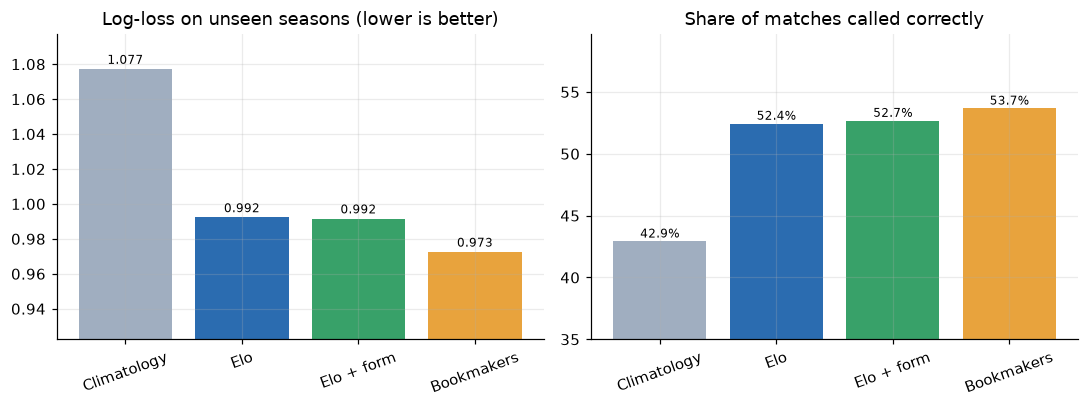

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
colors = [GREY, BLUE, "#38a169", AMBER]
axes[0].bar(results.index, results.log_loss, color=colors)
for x, v in enumerate(results.log_loss):
    axes[0].text(x, v + 0.003, f"{v:.3f}", ha="center", fontsize=8)
axes[0].set_ylim(results.log_loss.min() - 0.05, results.log_loss.max() + 0.02)
axes[0].set_title("Log-loss on unseen seasons (lower is better)")
axes[1].bar(results.index, results.accuracy * 100, color=colors)
for x, v in enumerate(results.accuracy * 100):
    axes[1].text(x, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)
axes[1].set_ylim(35, results.accuracy.max() * 100 + 6)
axes[1].set_title("Share of matches called correctly")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

## 5. Are the probabilities honest?

Accuracy only counts the single most likely outcome. A **reliability curve** asks a better question: of all the matches where a model said "60% chance of a home win", did the home team really win about 60% of the time?

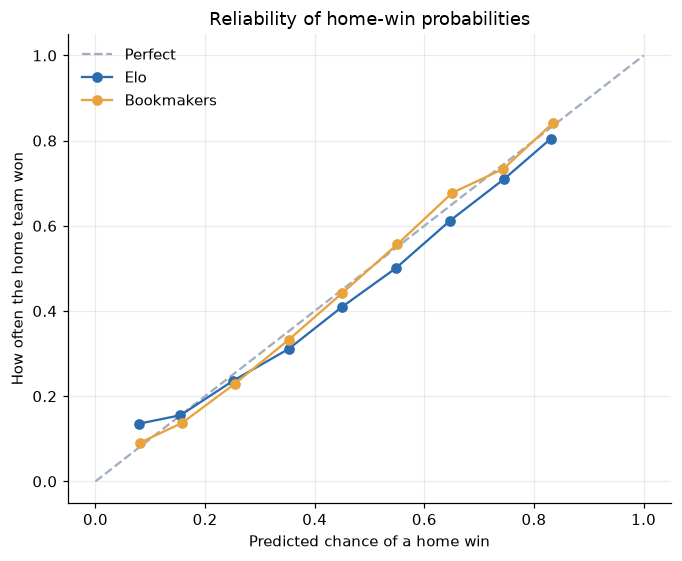

In [10]:
bins = np.linspace(0, 1, 11)
fig, ax = plt.subplots(figsize=(6.3, 5.2))
ax.plot([0, 1], [0, 1], color=GREY, ls="--", label="Perfect")
for name, color in [("Elo", BLUE), ("Bookmakers", AMBER)]:
    p_home = probs[name][evaluate_on, 0]
    won = (y_all[evaluate_on] == 0).astype(float)
    idx = np.digitize(p_home, bins) - 1
    pts = [(p_home[idx == b].mean(), won[idx == b].mean(), (idx == b).sum()) for b in range(10) if (idx == b).sum() >= 40]
    ax.plot([p[0] for p in pts], [p[1] for p in pts], marker="o", color=color, label=name)
ax.set_xlabel("Predicted chance of a home win")
ax.set_ylabel("How often the home team won")
ax.set_title("Reliability of home-win probabilities")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### Why does Elo lean towards the home team?

In the middle of the chart the Elo model is too optimistic about home wins. The model was fitted on 2012-2017 and tested on 2019-2025, and home advantage has changed in between, which the table below shows.

In [11]:
periods = {"2012/13-2016/17 (fitting)": train, "2017/18-2018/19 (validation)": valid, "2019/20-2024/25 (test)": test}
pd.DataFrame({
    name: {"home wins": (matches.result[m] == "H").mean(), "draws": (matches.result[m] == "D").mean(),
          "away wins": (matches.result[m] == "A").mean()} for name, m in periods.items()}).T.round(3)

,home wins,draws,away wins
2012/13-2016/17 (fitting),0.460,0.248,0.291
2017/18-2018/19 (validation),0.450,0.252,0.298
2019/20-2024/25 (test),0.429,0.252,0.319


## 6. What the model has learned

The fitted Elo model turns the rating gap into probabilities. A home team with no rating advantage still wins about 4 in 10 matches because of the home bonus, and the **draw** probability peaks when the teams are evenly matched and shrinks as the gap grows.

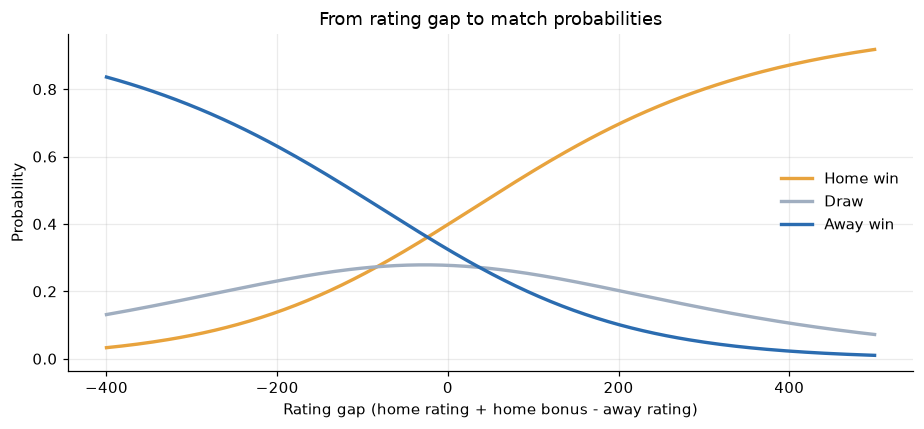

,rating gap,P(home),P(draw),P(away)
0,0,0.398,0.277,0.324
1,100,0.557,0.251,0.192
2,200,0.696,0.202,0.101
3,300,0.800,0.150,0.049


In [12]:
gap = np.linspace(-400, 500, 200)
curve = fit_predict(["elo_diff"])[1]
scaler = StandardScaler().fit(matches.loc[train, ["elo_diff"]])
p = curve.predict_proba(scaler.transform(pd.DataFrame({"elo_diff": gap})))
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(gap, p[:, 0], color=AMBER, lw=2.2, label="Home win")
ax.plot(gap, p[:, 1], color=GREY, lw=2.2, label="Draw")
ax.plot(gap, p[:, 2], color=BLUE, lw=2.2, label="Away win")
ax.set_xlabel("Rating gap (home rating + home bonus - away rating)")
ax.set_ylabel("Probability")
ax.set_title("From rating gap to match probabilities")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
pd.DataFrame({"rating gap": [0, 100, 200, 300], "P(home)": np.interp([0, 100, 200, 300], gap, p[:, 0]).round(3),
              "P(draw)": np.interp([0, 100, 200, 300], gap, p[:, 1]).round(3),
              "P(away)": np.interp([0, 100, 200, 300], gap, p[:, 2]).round(3)})

## What the results say

- **Results alone get you most of the way.** On 10,702 matches from the 2019/20 to 2024/25 seasons (never used for fitting), always predicting the average home / draw / away split has a log-loss of 1.077. Elo ratings built only from past scores bring it down to 0.992, which is 81% of the distance to the bookmakers' 0.973. Accuracy rises from 42.9% to 52.4%.
- **Recent form adds almost nothing.** Adding points and goal difference over the last five matches moves log-loss from 0.9923 to 0.9916, because the rating already contains the recent results.
- **The bookmakers are still better.** Bet365's margin-free probabilities score 0.973 and call 53.7% of matches correctly, against 52.4% for Elo. They know things a results-only model cannot: injuries, line-ups, travel and where the money is being bet. A gap of 0.02 in log-loss is small but real, and no tuning of a pure rating model is likely to close it.
- **The model's weakness is a changing world, not its settings.** Home wins fell from 46.0% of matches in the fitting seasons to 42.9% in the test seasons (away wins rose from 29.1% to 31.9%). The Elo model, calibrated on the earlier period, overstates home wins by roughly four to five points in the middle of the reliability curve, while the bookmakers stay close to the diagonal because they keep adjusting. A model like this has to be refitted regularly.
- **The settings hardly matter.** Every `k` from 10 to 40 gives almost the same validation loss (about 0.976), and the home bonus is absorbed by the regression's intercept. That is a feature of Elo: it is simple and robust.
- **Draws are hard to call.** For two evenly matched teams the model gives a 40% home win, 28% draw and 32% away win. The probability of a draw peaks at about 28% and falls as the rating gap grows (15% at a gap of 300 points), so a draw is never the single most likely outcome.
- **What the ratings say now.** On the last day in the data the top rated clubs inside each league were Liverpool (1724), Bayern Munich (1749), Barcelona (1752), Paris Saint-Germain (1779) and Inter (1746). Ratings are comparable only within a league, so these numbers do not say Paris is stronger than Barcelona.

**Limits:** each league is its own rating pool, promoted clubs start at 1450, and nothing about injuries, line-ups or transfers is used. Bookmaker probabilities are rescaled proportionally to remove the margin, which is one of several ways to do it.

**Techniques covered:** Elo rating updates with a goal-difference multiplier, time-based train / validation / test split, multinomial logistic regression, log-loss, Brier score and ranked probability score, reliability curves.
